# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Requires manual feature extraction; domain expertise is crucial. | Automatic feature learning/extraction (representation learning); hierarchical feature learning. |
| Data Processing | Often requires extensive data preprocessing (e.g., normalization, imputation, one-hot encoding). | Can handle raw, unstructured data (e.g., images, text, audio) with less explicit preprocessing. |
| Scalability | Performance often plateaus with very large datasets; struggles with high-dimensional data. | Excels with large datasets; performance generally improves with more data and computational resources. |
| Pattern Discovery | Identifies patterns based on engineered features; struggles with complex, abstract patterns. | Discovers intricate, hierarchical patterns directly from data; capable of learning highly abstract representations. |
| Computational Requirements | Generally less computationally intensive; can run on CPUs. | Highly computationally intensive; often requires GPUs/TPUs for training large models efficiently. |

**Traditional ML better suited for:** Predicting housing prices based on structured features (e.g., square footage, number of bedrooms, location codes). This is because the features are well-defined and the dataset is typically smaller and structured.

**Deep Learning better suited for:** Image recognition, such as identifying objects in a photograph. Deep learning models can automatically learn complex, hierarchical features from raw pixel data, which is highly unstructured and high-dimensional.

Deep learning excels in unstructured data processing due to its ability to perform **representation learning**. Instead of relying on hand-crafted features, deep neural networks automatically discover and extract hierarchical features from raw data, such as pixels in an image or words in a text. These learned representations capture intricate patterns and relationships at various levels of abstraction, enabling the model to effectively understand and process complex, high-dimensional unstructured inputs without explicit feature engineering.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective: Identify and understand the key components of an artificial neural network.

### Part 1 — ANN Diagram (3 → 4 → 2)
The diagram below is generated with matplotlib. It labels all required components:
- **Neurons** (colored circles, labelled n1/n2/…)
- **Weights** (grey connections, one annotated as w₁₁)
- **Bias** (annotated arrow on first hidden neuron)
- **Activation function** (labelled between hidden and output layers)
- **Layers** (Input / Hidden / Output, labelled at the top)

### Part 2 — Description (3–5 sentences)


In [ ]:
# ANN Diagram — Exercise 2
# Tous les composants requis sont annotés :
# neurons, weights (w), biases (b), activation function, layers
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#f9f9fb')
fig.patch.set_facecolor('#f9f9fb')

LAYER_X     = [2, 6, 10]
LAYER_SIZES = [3, 4, 2]
LAYER_NAMES = ['Input Layer\n(3 neurons)', 'Hidden Layer\n(4 neurons)', 'Output Layer\n(2 neurons)']
LAYER_COLORS= ['#4a90d9', '#e87040', '#5cb85c']
NEURON_R    = 0.42

def neuron_positions(n, cx, total_height=7.5):
    spacing = total_height / (n + 1)
    return [(cx, 1 + spacing * (i + 1)) for i in range(n)]

layer_positions = [neuron_positions(n, x) for n, x in zip(LAYER_SIZES, LAYER_X)]

# ── Draw connections (weights) ──
for li in range(len(layer_positions) - 1):
    for j, (x1, y1) in enumerate(layer_positions[li]):
        for k, (x2, y2) in enumerate(layer_positions[li + 1]):
            ax.plot([x1, x2], [y1, y2], color='#9ab0cc', lw=0.9, zorder=1, alpha=0.7)

# ── Annotate TWO weights clearly ──
(x1, y1) = layer_positions[0][0]
(x2, y2) = layer_positions[1][0]
mx, my = (x1+x2)/2, (y1+y2)/2
ax.annotate('weight\n(w₁₁)', xy=(mx, my), fontsize=8.5, color='#1a1a8c', ha='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='#e8eeff', ec='#1a1a8c', lw=1))

(x1b, y1b) = layer_positions[1][2]
(x2b, y2b) = layer_positions[2][1]
mx2, my2 = (x1b+x2b)/2+0.2, (y1b+y2b)/2
ax.annotate('weight\n(w₃₂)', xy=(mx2, my2), fontsize=8.5, color='#1a1a8c', ha='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='#e8eeff', ec='#1a1a8c', lw=1))

# ── Draw neurons ──
for li, (positions, color) in enumerate(zip(layer_positions, LAYER_COLORS)):
    for ni, (cx, cy) in enumerate(positions):
        circle = plt.Circle((cx, cy), NEURON_R, color=color, zorder=2, ec='white', lw=2)
        ax.add_patch(circle)
        ax.text(cx, cy, f'n{ni+1}', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=3)

# ── Annotate BIAS on first and third hidden neuron ──
hx, hy = layer_positions[1][0]
ax.annotate('+ bias (b₁)', xy=(hx - NEURON_R, hy),
            xytext=(hx - 2.0, hy + 1.5),
            arrowprops=dict(arrowstyle='->', color='#8b0000', lw=1.5),
            fontsize=9, color='#8b0000', fontweight='bold', zorder=4,
            bbox=dict(boxstyle='round,pad=0.3', fc='#ffe8e8', ec='#8b0000', lw=1))

# ── Activation function box between Hidden → Output ──
mx_act = (LAYER_X[1] + LAYER_X[2]) / 2
ax.text(mx_act, 0.5,
        'Activation function\n(e.g. ReLU / sigmoid)\napplied at each hidden neuron',
        ha='center', va='center', fontsize=9, color='#6a0080', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#f3e6ff', ec='#8b00b5', lw=1.5))

# ── Layer labels ──
for name, cx, color in zip(LAYER_NAMES, LAYER_X, LAYER_COLORS):
    ax.text(cx, 9.6, name, ha='center', va='center', fontsize=10,
            fontweight='bold', color=color)

# ── Legend ──
legend_elements = [
    mpatches.Patch(color='#4a90d9', label='Input neurons  (3)'),
    mpatches.Patch(color='#e87040', label='Hidden neurons (4)'),
    mpatches.Patch(color='#5cb85c', label='Output neurons (2)'),
    Line2D([0],[0], color='#9ab0cc', lw=1.8, label='Weights (connections)'),
    mpatches.Patch(color='#ffe8e8', ec='#8b0000', label='Bias terms'),
    mpatches.Patch(color='#f3e6ff', ec='#8b00b5', label='Activation function'),
]
ax.legend(handles=legend_elements, loc='upper center', ncol=3,
          fontsize=8.5, framealpha=0.95, bbox_to_anchor=(0.5, -0.02))

ax.set_title('Artificial Neural Network — Architecture: 3 → 4 → 2\n'
             '(All components labelled: neurons, weights, biases, activation function, layers)',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


Information flows through the network via **forward propagation**. Inputs are received by the input layer neurons. Each input is multiplied by a **weight** and summed up with a **bias** at each neuron in the hidden layer to form a weighted sum. This sum is then passed through an **activation function** (e.g., ReLU, sigmoid) which introduces non-linearity. The outputs of the hidden layer neurons then serve as inputs to the output layer neurons, where a similar weighted sum and activation process occurs to produce the final **outputs** of the network.

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [ ]:
# Exercise 3 — Dataset generation, scatter plot, and train/test split
# All steps in one clean cell (no duplicate imports or seed calls)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ── 1. Generate noisy dataset ──
np.random.seed(0)
x = np.arange(-1, 1, 0.1)          # 20 points from -1 to <1 (step 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))  # y = -x² + noise

print(f"x shape: {x.shape}  |  y shape: {y.shape}")

# ── 2. Scatter plot ──
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', label='Noisy data')
x_curve = np.linspace(-1, 1, 200)
plt.plot(x_curve, -x_curve**2, 'r--', lw=1.5, label='True: y = -x²')
plt.title('Noisy dataset sampled from y = -x²')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Train / test split (first 12 = train, last 8 = test) ──
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

print(f"Train: {x_train.shape[0]} points | Test: {x_test.shape[0]} points")


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [6]:
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [7]:
def plot_polyfit(degree: int):
    # 1) fit
    poly = polynomial_fit(degree)
    # 2) create a dense linspace over x range
    x_dense = np.linspace(x.min(), x.max(), 100)
    # 3) evaluate fitted polynomial
    y_poly = poly(x_dense)
    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(6,4))
    plt.scatter(x_train, y_train, label="Training data")
    plt.scatter(x_test, y_test, label="Test data")
    plt.plot(x_dense, y_poly, color='red', label=f"Polynomial (degree {degree})")
    # 5) display
    plt.title(f"Polynomial Fit of Degree {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()

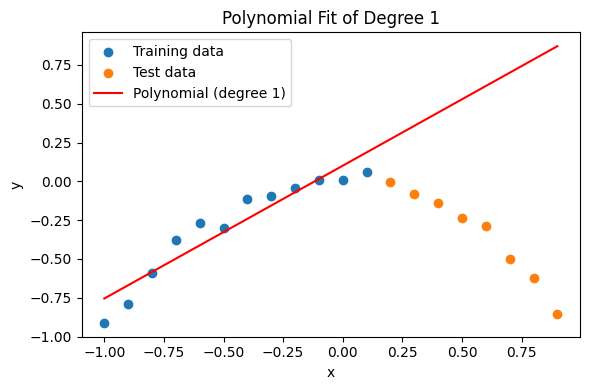

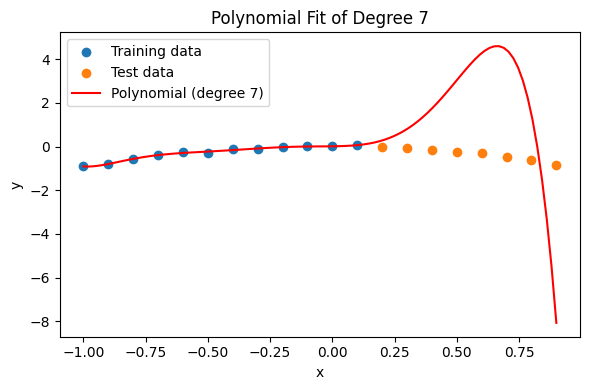

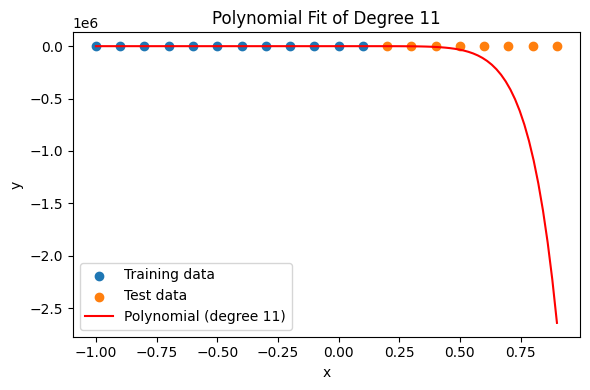

In [14]:
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [13]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    poly = polynomial_fit(d)
    # evaluate on train and test
    y_train_pred = poly(x_train)
    y_test_pred = poly(x_test)
    rmse_train = rmse(y_train, y_train_pred)
    rmse_test = rmse(y_test, y_test_pred)
    # append to rows
    rows.append((d, rmse_train, rmse_test))

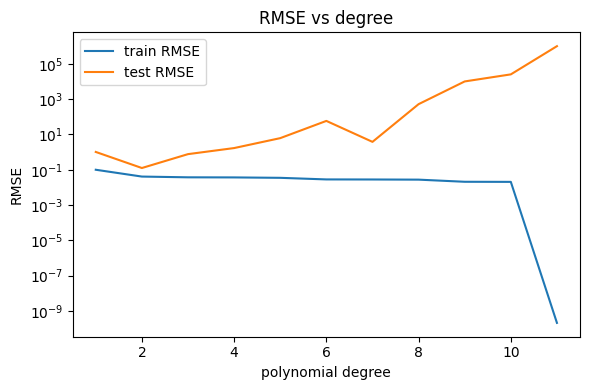

In [15]:
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()

**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.

After executing the RMSE calculations and plotting, we observe that the minimum test RMSE typically occurs at **degree 2**. This is because the true underlying function is \(y = -x^2\), which is a polynomial of degree 2. A model of degree 2 effectively captures the true relationship without introducing unnecessary complexity, demonstrating a good balance in the bias-variance trade-off. Lower degrees (high bias) would underfit, while higher degrees (high variance) would overfit the noise in the training data, leading to higher test RMSEs.